# Arabic Dialect Detection with Qwen2 (QLoRA)

Fine-tunes **`Qwen/Qwen2-1.5B`** using **QLoRA** (4-bit quantization + LoRA adapters) on the IADD dataset.

> **Note:** Qwen2-1.5B is used as the open LLM model (completely open, no approval needed, strong Arabic support). It plays the same role as LLaMA in the comparison. Once LLaMA access is approved, change `MODEL_NAME` in the config cell.

**Same task as AraBERT notebook** — results from both are compared at the end.

| Code | Region | Countries |
|------|--------|-----------|
| MGH | Maghrebi | Algeria, Morocco, Tunisia |
| LEV | Levantine | Syria, Palestine, Jordan, Lebanon |
| EGY | Egyptian | Egypt |
| IRQ | Iraqi | Iraq |
| GLF | Gulf | Gulf states |
| general | General | Mixed |

**Why QLoRA?** A 1B+ parameter model won't fit in Colab's T4 VRAM at full precision. QLoRA loads weights in 4-bit and trains only ~1% of parameters via LoRA adapters.

> **Before running:** Enable GPU via *Runtime → Change runtime type → T4 GPU*

## 1. Setup

In [ ]:
%%capture
!pip install transformers peft bitsandbytes accelerate datasets scikit-learn pandas numpy matplotlib seaborn requests

In [ ]:
# No HuggingFace login needed — Qwen2-1.5B is fully open
# (To switch to LLaMA after approval, uncomment below and change MODEL_NAME)
# from huggingface_hub import notebook_login
# notebook_login()
print("Qwen2-1.5B is open — no login required.")

Qwen2-1.5B is open — no login required.


In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Enable via Runtime → Change runtime type → T4 GPU")

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Imports & Configuration

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    BitsAndBytesConfig, TrainingArguments, Trainer, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import json, os, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Imports done.")

Imports done.


In [ ]:
MODEL_NAME         = "Qwen/Qwen2-1.5B"
MODEL_DISPLAY_NAME = "Qwen2"
MAX_LEN     = 128
BATCH_SIZE  = 8
GRAD_ACCUM  = 4       # effective batch = 32
EPOCHS      = 3
LR          = 2e-4
LORA_R      = 16
LORA_ALPHA  = 32
print(f"Model: {MODEL_NAME}")

Model: Qwen/Qwen2-1.5B


## 3. Load IADD Dataset

In [ ]:
def load_iadd():
    urls = [
        "https://raw.githubusercontent.com/JihadZa/IADD/main/IADD.json",
        "https://raw.githubusercontent.com/JihadZa/IADD/master/IADD.json",
    ]
    for url in urls:
        try:
            print(f"Trying: {url}")
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            data = r.json()
            print(f"Successfully loaded {len(data):,} samples")
            return data
        except Exception as e:
            print(f"  Failed: {e}")

    print("\nAutomatic download failed. Upload IADD.json manually:")
    print("  from google.colab import files")
    print("  uploaded = files.upload()")
    print("  data = json.loads(list(uploaded.values())[0])")
    return None

data = load_iadd()
df = pd.DataFrame(data)
print(f"Columns: {list(df.columns)}")
df.head()

Trying: https://raw.githubusercontent.com/JihadZa/IADD/main/IADD.json
Successfully loaded 135,804 samples
Columns: ['Sentence', 'Region', 'DataSource', 'Country']


,Sentence,Region,DataSource,Country
0,: وش فيك تسألني إذا كنت غالي؟ غالي وتسوى من ...,GLF,DART,NA
1,روان بن حسين مستحيل ما ادز شي بسناب حتى لو ما...,GLF,DART,NA
2,: ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...,GLF,DART,NA
3,: فارس_البقميk_محب أطيب من الطيب واصل الطيب ...,GLF,DART,NA
4,شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...,GLF,DART,NA


## 4. Exploratory Data Analysis

=== Dataset Overview ===
Shape: (135804, 4)

Region distribution:
Region
LEV        87573
MGH        33996
GLF         6682
EGY         4837
general     2500
IRQ          216
Name: count, dtype: int64

Country distribution:
Country
Syria        44972
Palestine    17855
NA           16441
Algeria      14426
Tunisia      11998
Lebanon      10829
Morocco       7213
Jordan        7017
Egypt         4837
Iraq           216
Name: count, dtype: int64


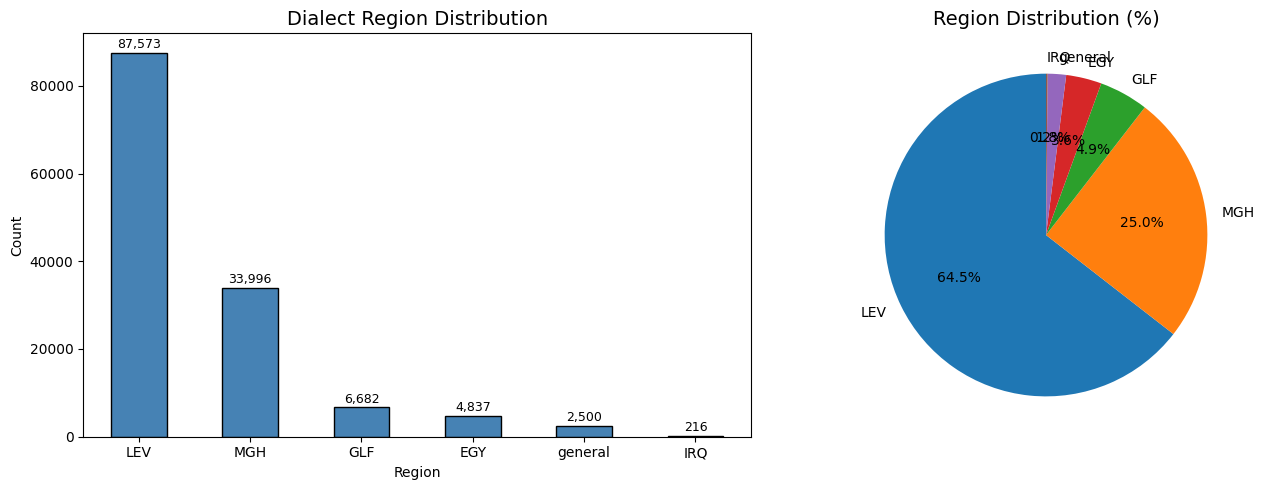


Average word count by region:
         mean  median   max
Region                     
EGY      24.0    13.0  1303
GLF      15.7    10.0  7530
IRQ      12.7    12.0    30
LEV      13.0     9.0   690
MGH       7.6     5.0  1164
general   9.0     6.0   154


In [ ]:
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nRegion distribution:")
print(df["Region"].value_counts())
print(f"\nCountry distribution:")
print(df["Country"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["Region"].value_counts()

counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Dialect Region Distribution", fontsize=14)
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for bar, cnt in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=9)

counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Region Distribution (%)", fontsize=14); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("dialect_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Text length analysis
df["word_count"] = df["Sentence"].astype(str).apply(lambda x: len(x.split()))
print("\nAverage word count by region:")
print(df.groupby("Region")["word_count"].agg(["mean","median","max"]).round(1))

## 5. Preprocessing & Label Encoding

In [ ]:
# Drop missing / empty
df = df.dropna(subset=["Sentence"])
df["Sentence"] = df["Sentence"].astype(str).str.strip()
df = df[df["Sentence"].str.len() > 0].reset_index(drop=True)

# Encode labels
label_names = sorted(df["Region"].unique())
label2id = {l: i for i, l in enumerate(label_names)}
id2label  = {i: l for l, i in label2id.items()}
df["label"] = df["Region"].map(label2id)
NUM_LABELS = len(label2id)

print(f"Label mapping: {label2id}")
print(f"Number of classes: {NUM_LABELS}")
print(f"Total samples after cleaning: {len(df):,}")

Label mapping: {'EGY': 0, 'GLF': 1, 'IRQ': 2, 'LEV': 3, 'MGH': 4, 'general': 5}
Number of classes: 6
Total samples after cleaning: 135,804


## 6. Train / Val / Test Split  (70 / 15 / 15, stratified)

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"\nTrain class distribution:")
print(train_df["Region"].value_counts())

Train: 95,062 | Val: 20,371 | Test: 20,371

Train class distribution:
Region
LEV        61301
MGH        23797
GLF         4677
EGY         3386
general     1750
IRQ          151
Name: count, dtype: int64


## 7. Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Qwen2 may not have a pad token by default — use eos token instead
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print("pad_token set to eos_token")

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: Qwen/Qwen2-1.5B
Vocab size: 151,643


## 8. QLoRA Configuration

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
print("4-bit BitsAndBytes config ready.")

4-bit BitsAndBytes config ready.


## 9. Load Qwen2 with 4-bit Quantization

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model.config.pad_token_id = tokenizer.pad_token_id

total = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {total:,}")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Total parameters: 888,625,664


## 10. Apply LoRA Adapters

In [ ]:
model = prepare_model_for_kbit_training(model)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

trainable params: 4,367,360 || all params: 1,548,090,880 || trainable%: 0.2821


## 11. PyTorch Dataset

In [ ]:
class ArabicDialectDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = ArabicDialectDataset(train_df["Sentence"].values, train_df["label"].values, tokenizer, MAX_LEN)
val_ds   = ArabicDialectDataset(val_df["Sentence"].values,   val_df["label"].values,   tokenizer, MAX_LEN)
test_ds  = ArabicDialectDataset(test_df["Sentence"].values,  test_df["label"].values,  tokenizer, MAX_LEN)
print(f"Datasets — Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Datasets — Train: 95,062 | Val: 20,371 | Test: 20,371


## 12. Class Weights (handle imbalance)

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_df["label"].values
)
WEIGHT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(WEIGHT_DEVICE)

print("Class weights (corrects for imbalance):")
for i, (lbl, w) in enumerate(zip(label_names, class_weights)):
    n = (train_df["label"] == i).sum()
    print(f"  {lbl:10s}: weight={w:.3f}  (n={n:,})")

Class weights (corrects for imbalance):
  EGY       : weight=4.679  (n=3,386)
  GLF       : weight=3.388  (n=4,677)
  IRQ       : weight=104.925  (n=151)
  LEV       : weight=0.258  (n=61,301)
  MGH       : weight=0.666  (n=23,797)
  general   : weight=9.054  (n=1,750)


## 13. Custom Weighted Trainer

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    float(accuracy_score(labels, preds)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted")),
        "f1_macro":    float(f1_score(labels, preds, average="macro")),
    }

## 14. Training

In [ ]:
warmup_steps = int(0.05 * (len(train_ds) // BATCH_SIZE) * EPOCHS)
print(f"Warmup steps: {warmup_steps}")

training_args = TrainingArguments(
    output_dir="./qwen2_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=100,
    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    remove_unused_columns=False,
)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Warmup steps: 1782


In [ ]:
print("Starting Qwen2 QLoRA fine-tuning...")
print(f"  Model:      {MODEL_NAME}")
print(f"  Epochs:     {EPOCHS} | Batch: {BATCH_SIZE} | Grad Accum: {GRAD_ACCUM} | LR: {LR}")
print(f"  LoRA:       r={LORA_R}, alpha={LORA_ALPHA}")
print(f"  Train:      {len(train_ds):,} samples")
print("-" * 50)
trainer.train()
print("Training complete.")

Starting Qwen2 QLoRA fine-tuning...
  Model:      Qwen/Qwen2-1.5B
  Epochs:     3 | Batch: 8 | Grad Accum: 4 | LR: 0.0002
  LoRA:       r=16, alpha=32
  Train:      95,062 samples
--------------------------------------------------


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 15. Evaluation

In [ ]:
print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
test_output = trainer.predict(test_ds)
preds       = np.argmax(test_output.predictions, axis=-1)
true_labels = test_output.label_ids

acc  = accuracy_score(true_labels, preds)
f1_w = f1_score(true_labels, preds, average="weighted")
f1_m = f1_score(true_labels, preds, average="macro")

print(f"Accuracy:    {acc:.4f}")
print(f"F1 Weighted: {f1_w:.4f}")
print(f"F1 Macro:    {f1_m:.4f}")
print("\nClassification Report:")
print(classification_report(
    true_labels, preds,
    target_names=[id2label[i] for i in range(NUM_LABELS)]
))

In [ ]:
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(NUM_LABELS)],
            yticklabels=[id2label[i] for i in range(NUM_LABELS)])
plt.title(f"{MODEL_DISPLAY_NAME} — Confusion Matrix", fontsize=14)
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
fname = MODEL_DISPLAY_NAME.lower().replace(" ", "_") + "_confusion_matrix.png"
plt.savefig(fname, dpi=150)
plt.show()
print(f"Saved: {fname}")

In [ ]:
results = {
    "model":       MODEL_DISPLAY_NAME,
    "accuracy":    float(acc),
    "f1_weighted": float(f1_w),
    "f1_macro":    float(f1_m),
    "report":      classification_report(
        true_labels, preds,
        target_names=[id2label[i] for i in range(NUM_LABELS)],
        output_dict=True
    )
}
fname = MODEL_DISPLAY_NAME.lower().replace(" ", "_") + "_results.json"
with open(fname, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {fname}")
print(f"Summary → Accuracy: {acc:.4f} | F1-W: {f1_w:.4f} | F1-M: {f1_m:.4f}")

## 16. Save LoRA Adapter

In [ ]:
model.save_pretrained("./qwen2_lora_adapter")
tokenizer.save_pretrained("./qwen2_lora_adapter")
print("LoRA adapter saved to ./qwen2_lora_adapter")
print("To reload: model = PeftModel.from_pretrained(base_model, './qwen2_lora_adapter')")

---

## Part 2 — Country-Level Classification

We now retrain Qwen2 to predict the **specific country** instead of the broader region.

| Code | Country | Region |
|------|---------|--------|
| DZ | Algeria | Maghrebi |
| TUN | Tunisia | Maghrebi |
| MAR | Morocco | Maghrebi |
| EGY | Egypt | Egyptian |
| IRQ | Iraq | Iraqi |
| SYR | Syria | Levantine |
| JOR | Jordan | Levantine |
| PSE | Palestine | Levantine |
| LBN | Lebanon | Levantine |

> Entries with `Country = "NA"` (Gulf + General, ~9,182 samples) are excluded — they have no specific country label.

**A fresh Qwen2 model is loaded** with 9 output classes + new LoRA adapters. The same QLoRA setup (4-bit quantization, `paged_adamw_8bit`) is reused so memory usage stays the same.

In [ ]:
# Filter out "NA" entries — Gulf and General have no specific country
df_country = df[df["Country"] != "NA"].copy().reset_index(drop=True)

print(f"Samples with known country: {len(df_country):,}")
print(f"Dropped (NA country):       {len(df) - len(df_country):,}")
print(f"\nCountry distribution:")
print(df_country["Country"].value_counts())

# EDA for countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_counts = df_country["Country"].value_counts()

country_counts.plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Country Distribution", fontsize=14)
axes[0].set_xlabel("Country"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for bar, cnt in zip(axes[0].patches, country_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=8)

country_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Country Distribution (%)", fontsize=14); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("country_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Encode country labels
country_names = sorted(df_country["Country"].unique())
c_label2id = {l: i for i, l in enumerate(country_names)}
c_id2label  = {i: l for l, i in c_label2id.items()}
df_country["c_label"] = df_country["Country"].map(c_label2id)
NUM_COUNTRY_LABELS = len(c_label2id)

print(f"Country label mapping: {c_label2id}")
print(f"Number of country classes: {NUM_COUNTRY_LABELS}")

# Stratified split (70 / 15 / 15)
c_train_df, c_temp_df = train_test_split(
    df_country, test_size=0.30, random_state=SEED, stratify=df_country["c_label"]
)
c_val_df, c_test_df = train_test_split(
    c_temp_df, test_size=0.50, random_state=SEED, stratify=c_temp_df["c_label"]
)
print(f"\nSplit → Train: {len(c_train_df):,} | Val: {len(c_val_df):,} | Test: {len(c_test_df):,}")
print(f"\nTrain country distribution:")
print(c_train_df["Country"].value_counts())

In [ ]:
# Reuse same tokenizer and ArabicDialectDataset class
c_train_ds = ArabicDialectDataset(c_train_df["Sentence"].values, c_train_df["c_label"].values, tokenizer, MAX_LEN)
c_val_ds   = ArabicDialectDataset(c_val_df["Sentence"].values,   c_val_df["c_label"].values,   tokenizer, MAX_LEN)
c_test_ds  = ArabicDialectDataset(c_test_df["Sentence"].values,  c_test_df["c_label"].values,  tokenizer, MAX_LEN)
print(f"Country Datasets — Train: {len(c_train_ds):,} | Val: {len(c_val_ds):,} | Test: {len(c_test_ds):,}")

In [ ]:
# Fresh Qwen2 model with 9 country output classes (4-bit quantized)
c_country_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_COUNTRY_LABELS,
    id2label=c_id2label,
    label2id=c_label2id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
c_country_model.config.pad_token_id = tokenizer.pad_token_id

# Apply LoRA adapters
c_country_model = prepare_model_for_kbit_training(c_country_model)
c_lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
)
c_country_model = get_peft_model(c_country_model, c_lora_cfg)
print(f"Country model loaded — {NUM_COUNTRY_LABELS} output classes")
c_country_model.print_trainable_parameters()

In [ ]:
c_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_COUNTRY_LABELS),
    y=c_train_df["c_label"].values
)
c_class_weights_tensor = torch.tensor(c_class_weights, dtype=torch.float).to(WEIGHT_DEVICE)

print("Country class weights (corrects for imbalance):")
for i, (lbl, w) in enumerate(zip(country_names, c_class_weights)):
    n = (c_train_df["c_label"] == i).sum()
    print(f"  {lbl:6s}: weight={w:.3f}  (n={n:,})")

In [ ]:
c_warmup_steps = int(0.05 * (len(c_train_ds) // BATCH_SIZE) * EPOCHS)
print(f"Country warmup steps: {c_warmup_steps}")

c_training_args = TrainingArguments(
    output_dir="./qwen2_country_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=c_warmup_steps,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=100,
    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    remove_unused_columns=False,
)

c_trainer = WeightedTrainer(
    class_weights=c_class_weights_tensor,
    model=c_country_model,
    args=c_training_args,
    train_dataset=c_train_ds,
    eval_dataset=c_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [ ]:
print("Starting Qwen2 Country-level QLoRA fine-tuning...")
print(f"  Model:  {MODEL_NAME}")
print(f"  Task:   {NUM_COUNTRY_LABELS}-class country classification")
print(f"  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | Grad Accum: {GRAD_ACCUM} | LR: {LR}")
print(f"  LoRA:   r={LORA_R}, alpha={LORA_ALPHA}")
print(f"  Train:  {len(c_train_ds):,} samples")
print("-" * 50)
c_trainer.train()
print("Country training complete.")

In [ ]:
print("=" * 50)
print("COUNTRY — TEST SET EVALUATION")
print("=" * 50)
c_test_output = c_trainer.predict(c_test_ds)
c_preds       = np.argmax(c_test_output.predictions, axis=-1)
c_true_labels = c_test_output.label_ids

c_acc  = accuracy_score(c_true_labels, c_preds)
c_f1_w = f1_score(c_true_labels, c_preds, average="weighted")
c_f1_m = f1_score(c_true_labels, c_preds, average="macro")

print(f"Accuracy:    {c_acc:.4f}")
print(f"F1 Weighted: {c_f1_w:.4f}")
print(f"F1 Macro:    {c_f1_m:.4f}")
print("\nClassification Report:")
print(classification_report(
    c_true_labels, c_preds,
    target_names=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)]
))

In [ ]:
c_cm = confusion_matrix(c_true_labels, c_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(c_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)],
            yticklabels=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)])
plt.title(f"{MODEL_DISPLAY_NAME} — Country Confusion Matrix", fontsize=14)
plt.ylabel("True Country"); plt.xlabel("Predicted Country")
plt.tight_layout()
plt.savefig("qwen2_country_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: qwen2_country_confusion_matrix.png")

In [ ]:
c_results = {
    "model":       f"{MODEL_DISPLAY_NAME} (Country)",
    "task":        "country",
    "accuracy":    float(c_acc),
    "f1_weighted": float(c_f1_w),
    "f1_macro":    float(c_f1_m),
    "report":      classification_report(
        c_true_labels, c_preds,
        target_names=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)],
        output_dict=True
    )
}
with open("qwen2_country_results.json", "w") as f:
    json.dump(c_results, f, indent=2)
print("Country results saved to qwen2_country_results.json")

c_country_model.save_pretrained("./qwen2_country_lora_adapter")
tokenizer.save_pretrained("./qwen2_country_lora_adapter")
print("Country LoRA adapter saved to ./qwen2_country_lora_adapter")

In [ ]:
print("=" * 60)
print("FINAL COMPARISON: Region vs Country Classification")
print("=" * 60)

with open("qwen2_results.json") as f:
    region_res = json.load(f)

summary = pd.DataFrame({
    "Task":        ["Region (6 classes)", "Country (9 classes)"],
    "Accuracy":    [region_res["accuracy"],    c_acc],
    "F1 Weighted": [region_res["f1_weighted"], c_f1_w],
    "F1 Macro":    [region_res["f1_macro"],    c_f1_m],
}).set_index("Task")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
w = 0.35
metrics_labels = ["Accuracy", "F1 Weighted", "F1 Macro"]
r_vals = [region_res["accuracy"], region_res["f1_weighted"], region_res["f1_macro"]]
c_vals = [c_acc, c_f1_w, c_f1_m]

bars1 = ax.bar(x - w/2, r_vals, w, label="Region (6 classes)",  color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, c_vals, w, label="Country (9 classes)", color="coral",     alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_DISPLAY_NAME}: Region vs Country Classification", fontsize=14)
ax.legend(fontsize=12); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("qwen2_region_vs_country.png", dpi=150)
plt.show()
print("Saved: qwen2_region_vs_country.png")